# Testing BaselineGCN - 2 layer conv nn on atom features only with relu activation functions

[10:12:39] Explicit valence for atom # 9 N, 5, is greater than permitted
Sanitization failed for molecule at index 2131, Name: ZINC16448882. Skipping sanitization: Explicit valence for atom # 9 N, 5, is greater than permitted
[10:12:39] Explicit valence for atom # 7 N, 5, is greater than permitted
Sanitization failed for molecule at index 2721, Name: ZINC15772239. Skipping sanitization: Explicit valence for atom # 7 N, 5, is greater than permitted
[10:12:39] Explicit valence for atom # 10 N, 5, is greater than permitted
Sanitization failed for molecule at index 3249, Name: ZINC11539132. Skipping sanitization: Explicit valence for atom # 10 N, 5, is greater than permitted
[10:12:40] Explicit valence for atom # 3 N, 5, is greater than permitted
Sanitization failed for molecule at index 5699, Name: ZINC17111082. Skipping sanitization: Explicit valence for atom # 3 N, 5, is greater than permitted
Skipping molecule ZINC59391023: Missing from JSON.
Skipping molecule ZINC00335972: Missing fro

num_node_features = 152
num_y_ATs = 75
FULL DATASET:


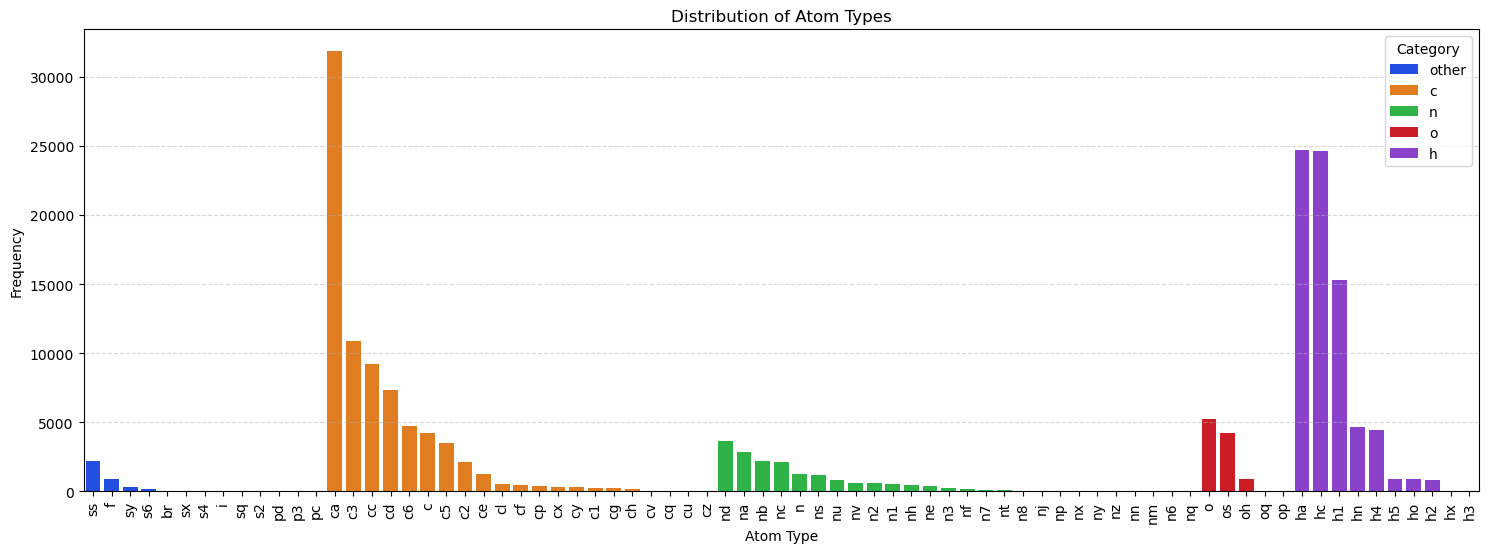

BaselineGCN - Number of parameters: 379467


---------KFOLD: 0----------
Epoch - 10: Train Loss: 0.7572 | Val Loss: 0.7526
Epoch - 20: Train Loss: 0.6693 | Val Loss: 0.6756


---------KFOLD: 1----------
Epoch - 10: Train Loss: 0.6198 | Val Loss: 0.6342
Epoch - 20: Train Loss: 0.6019 | Val Loss: 0.6211


---------KFOLD: 2----------
Epoch - 10: Train Loss: 0.5837 | Val Loss: 0.5875
Epoch - 20: Train Loss: 0.5737 | Val Loss: 0.5896


---------KFOLD: 3----------
Epoch - 10: Train Loss: 0.5627 | Val Loss: 0.5819
Epoch - 20: Train Loss: 0.5533 | Val Loss: 0.5827


---------KFOLD: 4----------
Epoch - 10: Train Loss: 0.5479 | Val Loss: 0.5637
Epoch - 20: Train Loss: 0.5439 | Val Loss: 0.5639


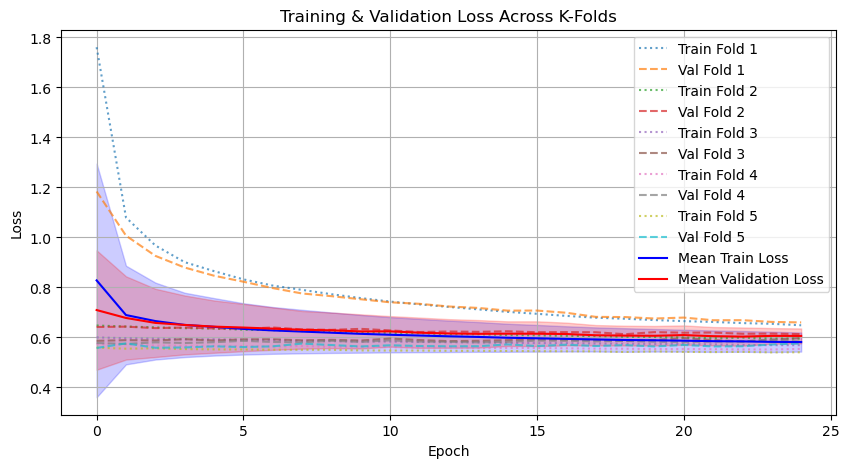

Evaluation Metrics: {'Accuracy': 0.777938188429045, 'F1-score': 0.7623253511260357}


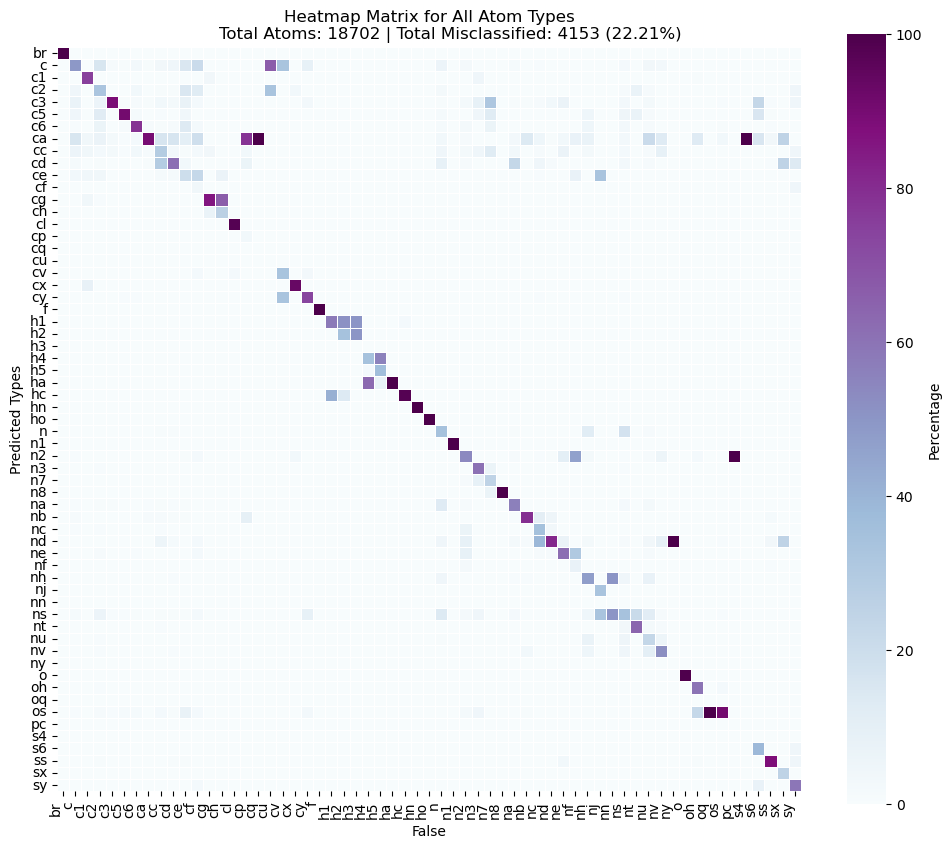

In [1]:
from atoMLtype.GNN.GNNmodel import GNNTrainer, BaselineGCN, BaselineGAT
from atoMLtype.GNN.GNNdataset import GNNdataset
from atoMLtype.utils.metrics import plot_atom_distribution, plot_full_heatmap, \
    plot_category_heatmap, plot_detailed_cross_category_heatmap
from torch.utils.data import random_split
import numpy as np

# Load the SDF file
sdf_path = "./data/parm_at_Frosst/zinc.sdf"
json_labels = "./data/antechamber/atomLabels_gaff2.json"

# Initialize dataset
gnn_test_dataset = GNNdataset(sdf_path, json_labels)
num_node_feat = gnn_test_dataset[0].x.shape[1]
num_y_ATs = len(set(gnn_test_dataset.all_labels))

print(f"num_node_features = {num_node_feat}")
print(f"num_y_ATs = {num_y_ATs}")


# Split Train and test dataset (95% train, 5% test)
train_size = int(0.90 * len(gnn_test_dataset))
test_size = len(gnn_test_dataset) - train_size
train_dataset, test_dataset = random_split(gnn_test_dataset, [train_size, test_size])

print("FULL DATASET:")
plot_atom_distribution(np.array(gnn_test_dataset.all_labels))

# Initialize BaselineGCN for classification
model = BaselineGCN(num_node_features=num_node_feat, num_atom_types=num_y_ATs, hidden_dim=512)
trainer = GNNTrainer(model, dataset=train_dataset, batch_size=32, learning_rate=0.001, \
                      epochs=25, k_folds=5, task="classification", random_seed=21)
trainer.train()
metrics = trainer.evaluate_model(test_dataset)

y_true_labels, y_pred_labels = trainer.predict(test_dataset)

plot_full_heatmap(y_true=y_true_labels, y_pred=y_pred_labels)


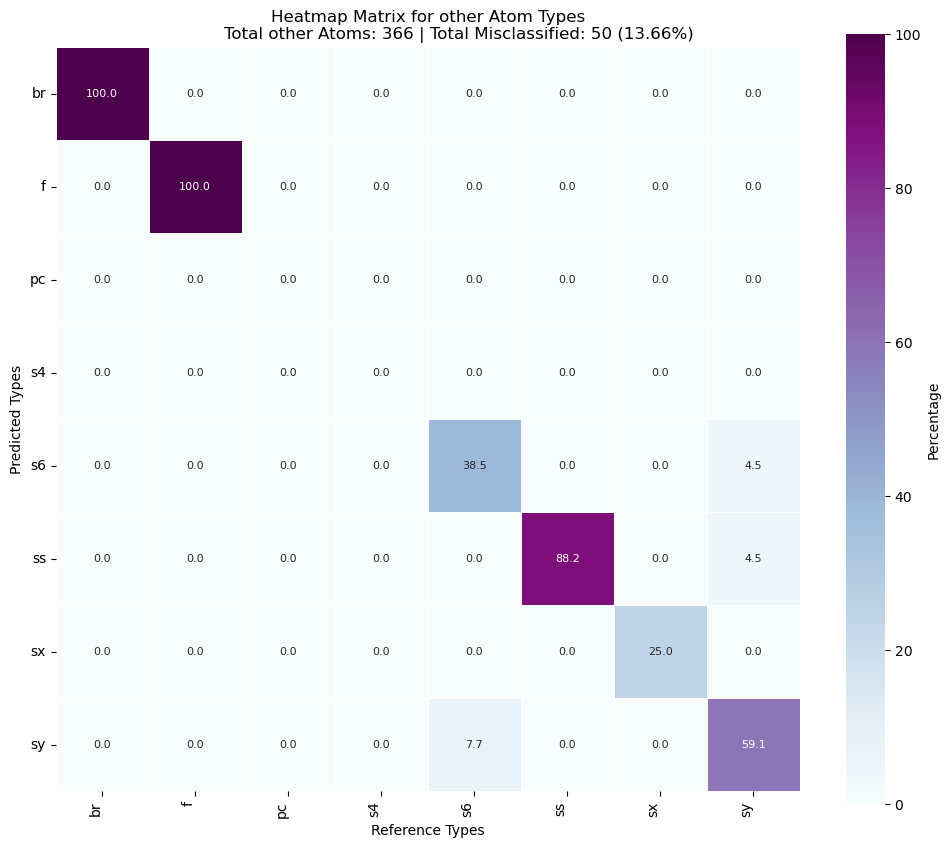

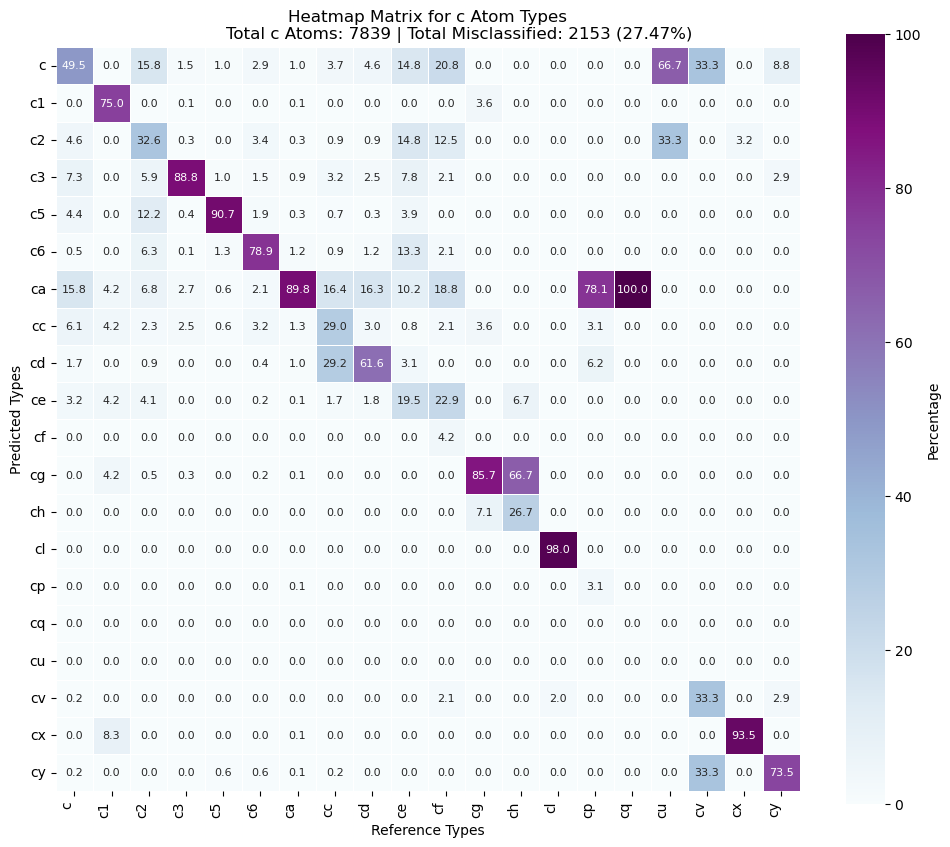

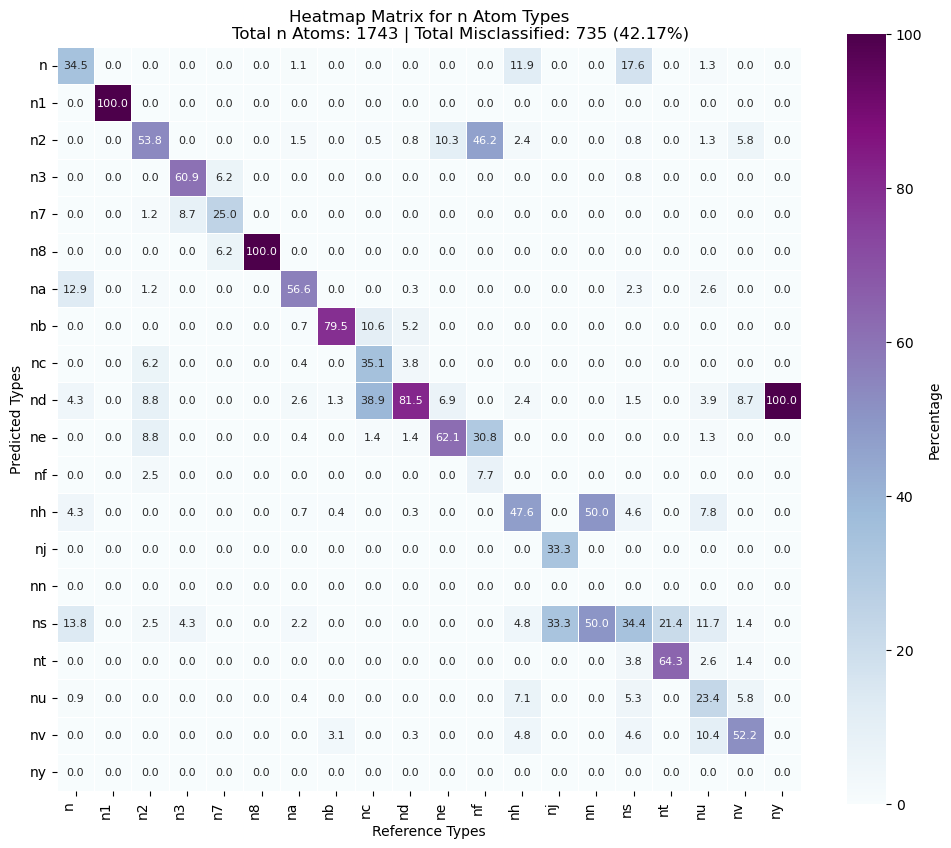

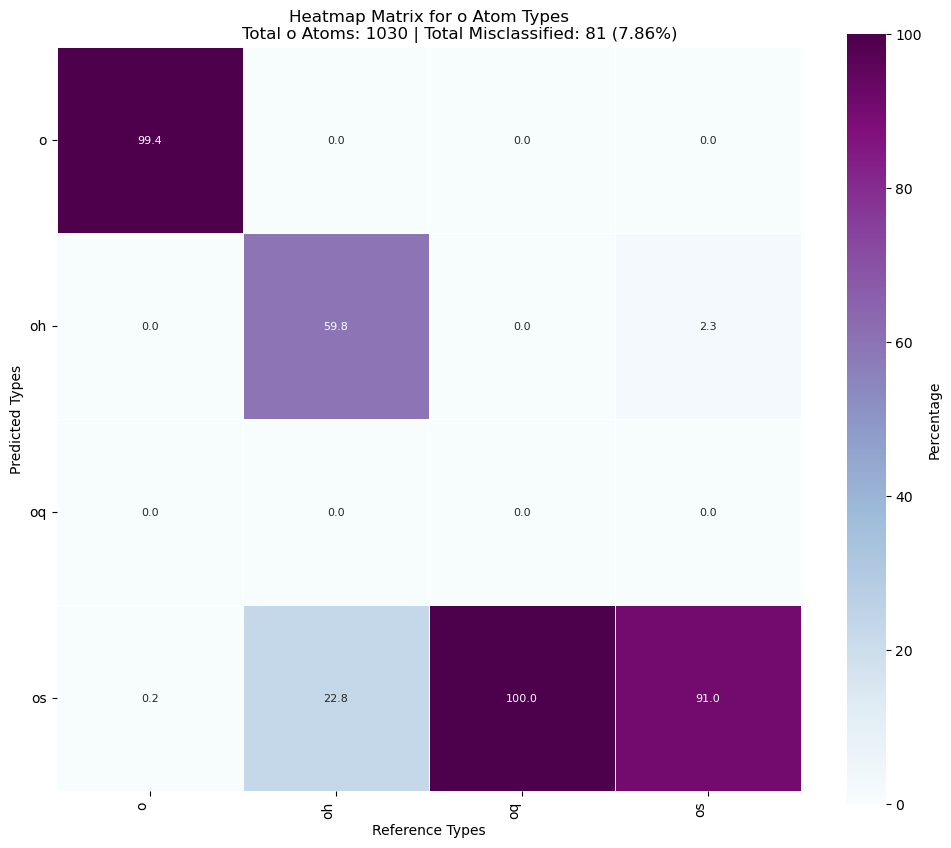

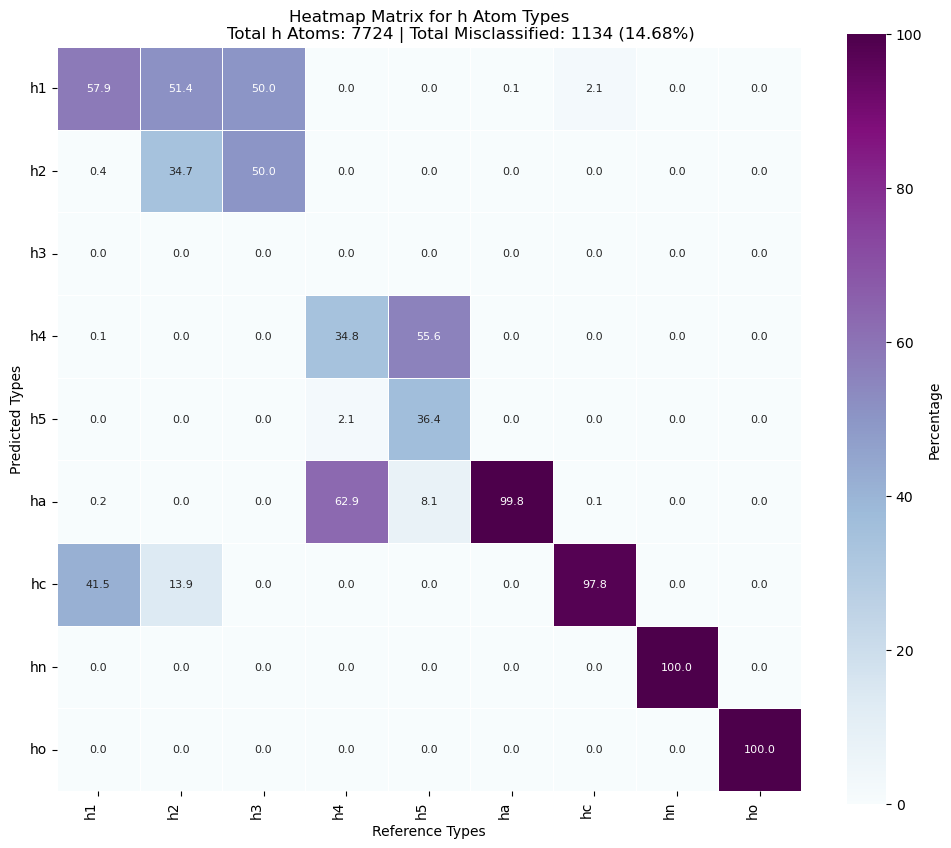

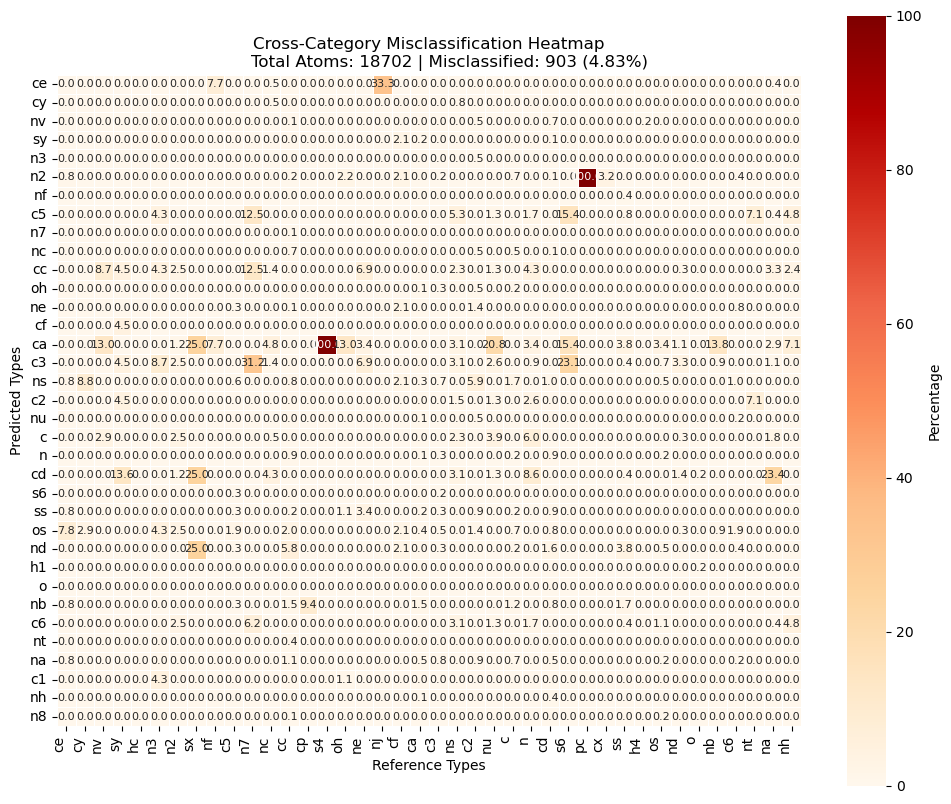

In [2]:
plot_category_heatmap(y_pred=y_pred_labels, y_true=y_true_labels)

plot_detailed_cross_category_heatmap(y_pred=y_pred_labels, y_true=y_true_labels)

# Testing BaselineGAT - 2 layer Graph Convulutions with attention mechanism nn on atom features only with elu activation functions

BaselineGAT - Number of parameters: 1406027


---------KFOLD: 0----------
Epoch - 10: Train Loss: 0.7498 | Val Loss: 0.7547
Epoch - 20: Train Loss: 0.7199 | Val Loss: 0.7262


---------KFOLD: 1----------
Epoch - 10: Train Loss: 0.7059 | Val Loss: 0.7081
Epoch - 20: Train Loss: 0.7011 | Val Loss: 0.7071


---------KFOLD: 2----------
Epoch - 10: Train Loss: 0.5881 | Val Loss: 0.5750
Epoch - 20: Train Loss: 0.4883 | Val Loss: 0.4982


---------KFOLD: 3----------
Epoch - 10: Train Loss: 0.4585 | Val Loss: 0.4777
Epoch - 20: Train Loss: 0.4447 | Val Loss: 0.4854


---------KFOLD: 4----------
Epoch - 10: Train Loss: 0.4475 | Val Loss: 0.4636
Epoch - 20: Train Loss: 0.4502 | Val Loss: 0.4529


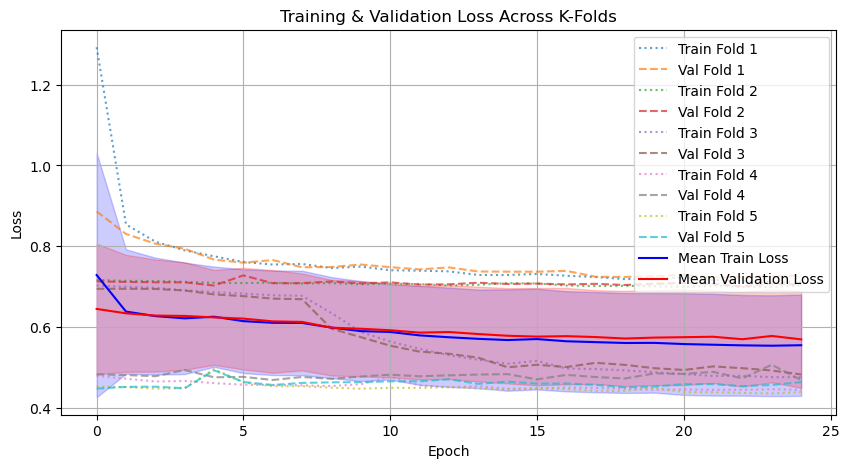

Evaluation Metrics: {'Accuracy': 0.8230135814351406, 'F1-score': 0.8070300148466028}


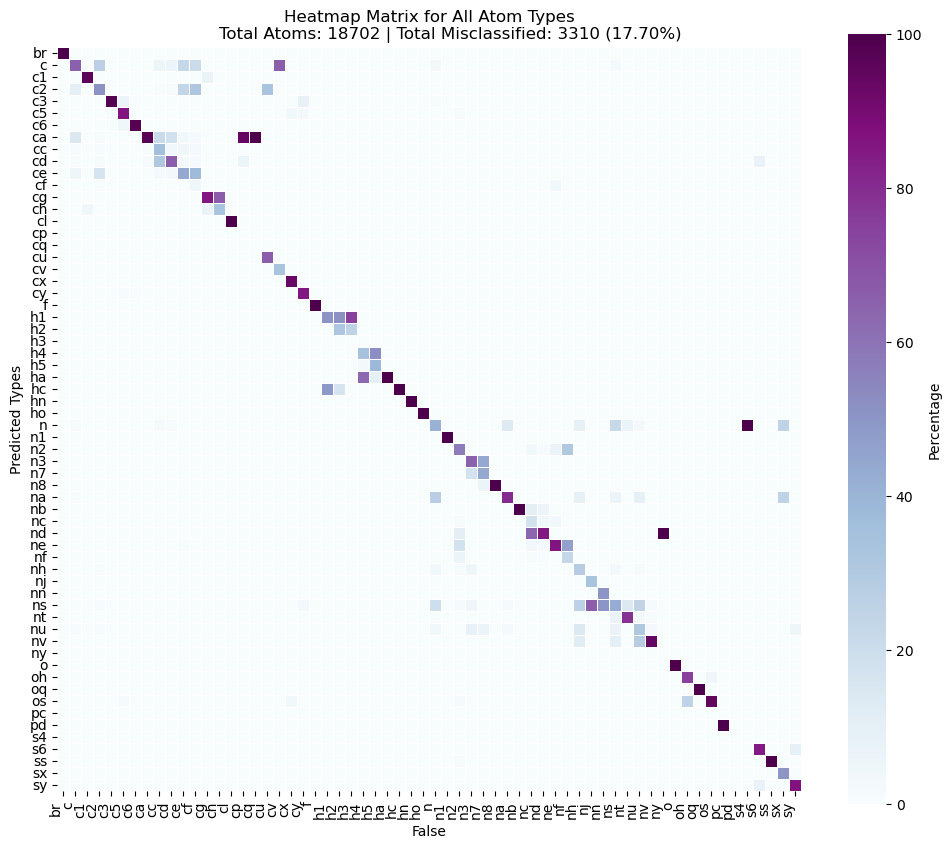

In [3]:
# Initialize baselineGNN for classification
model_GAT = BaselineGAT(num_node_features=num_node_feat, num_atom_types=num_y_ATs, hidden_dim=512, heads=4)
trainer_GAT = GNNTrainer(model_GAT, dataset=train_dataset, batch_size=32, learning_rate=0.001, \
                      epochs=25, k_folds=5, task="classification", random_seed=21)
trainer_GAT.train()
metrics_GAT = trainer_GAT.evaluate_model(test_dataset)

y_true_GAT, y_pred_GAT = trainer_GAT.predict(test_dataset)

plot_full_heatmap(y_true=y_true_GAT, y_pred=y_pred_GAT)


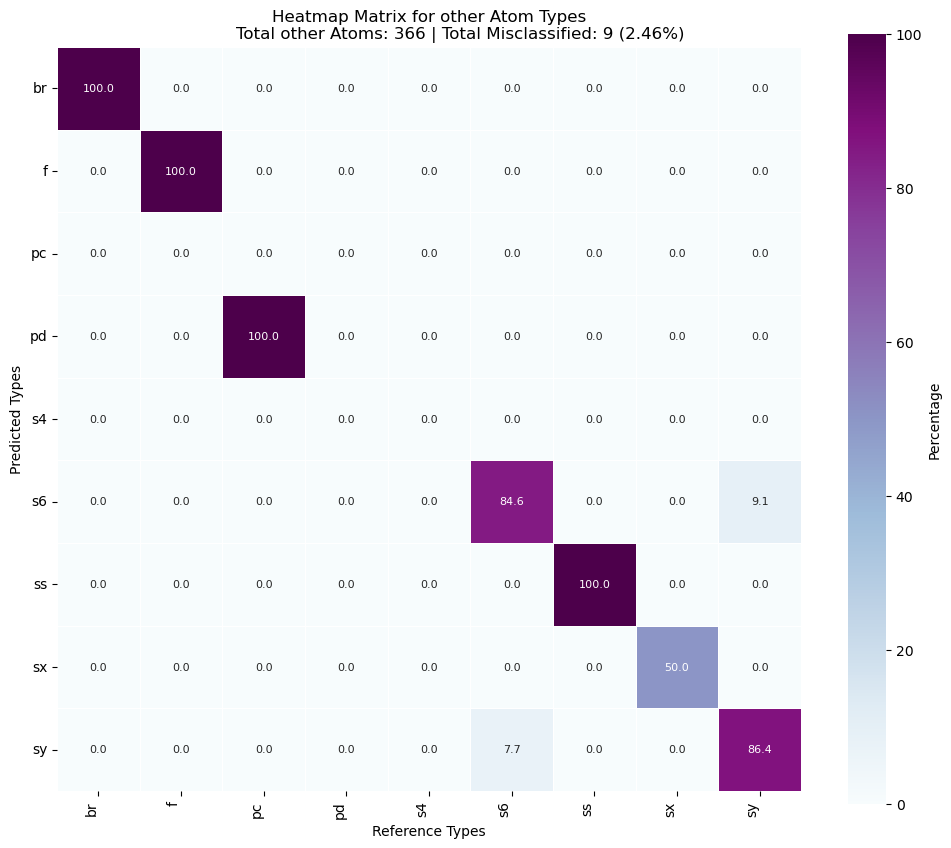

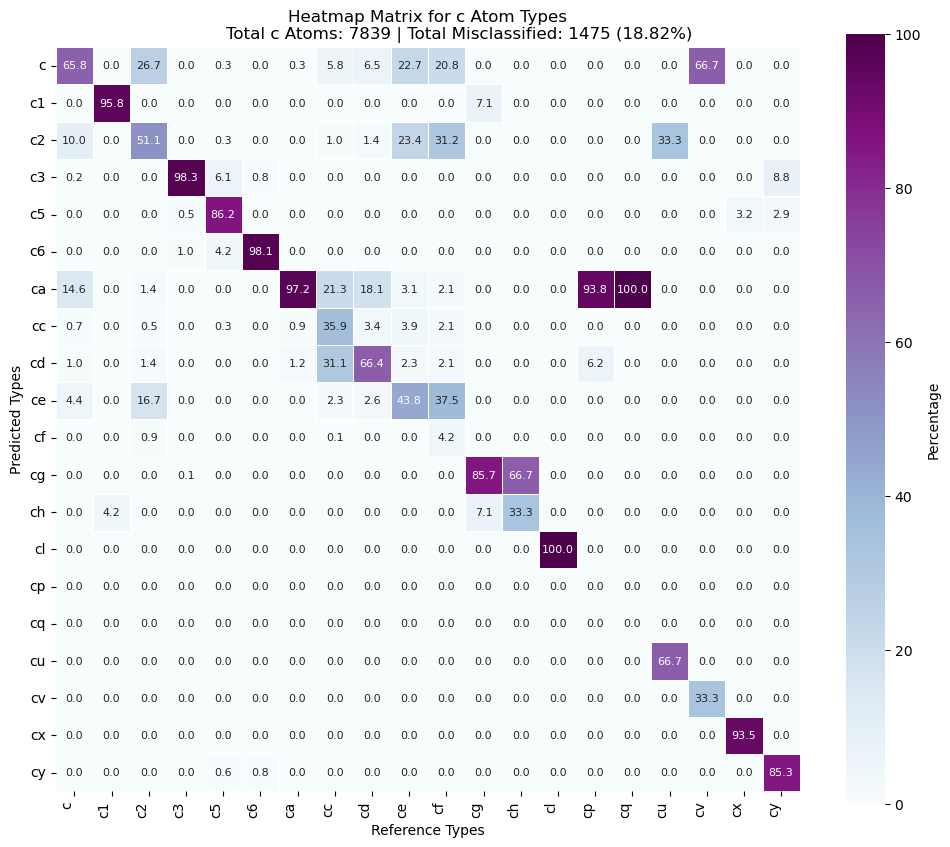

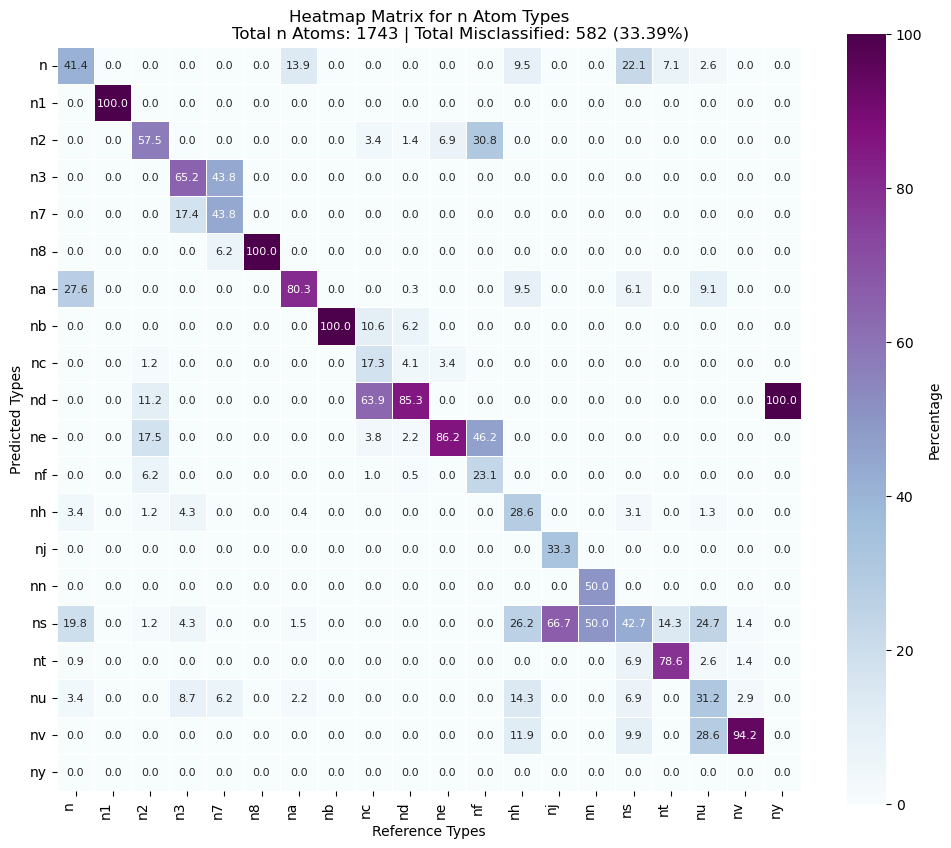

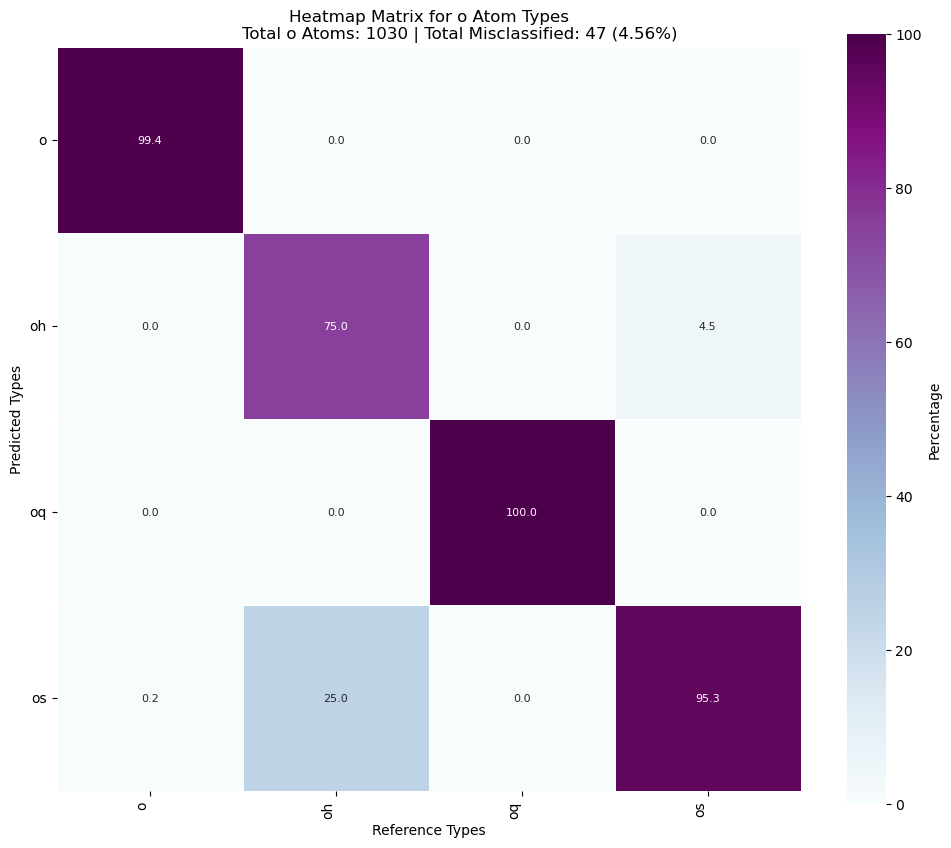

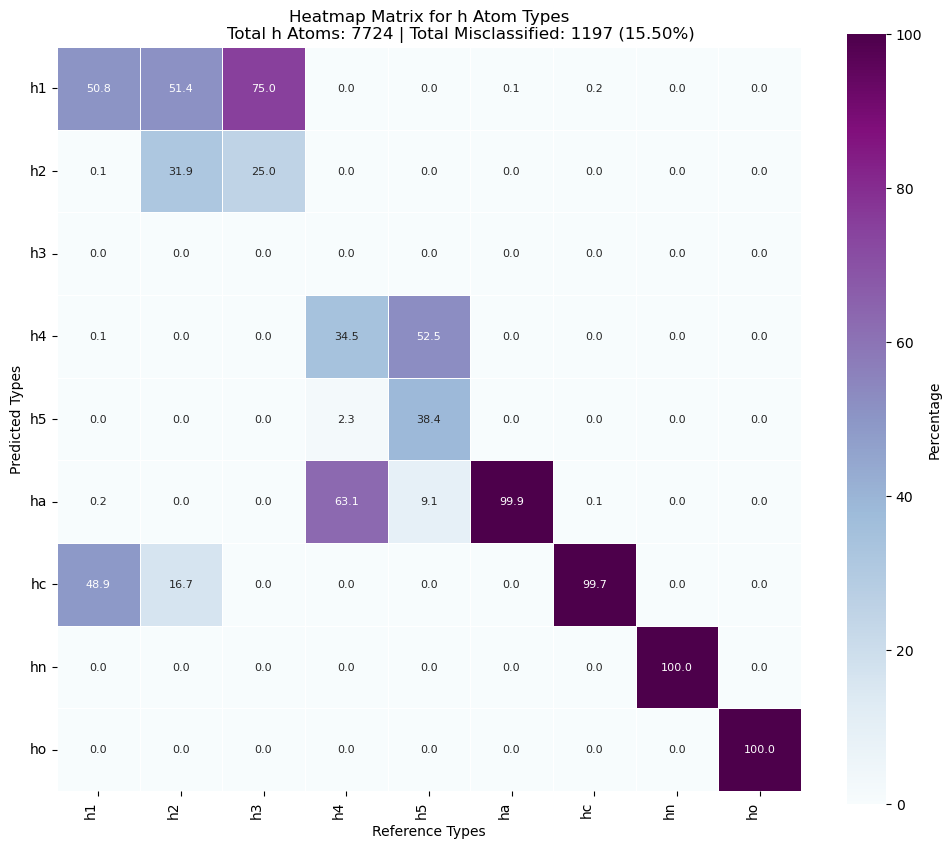

In [4]:
plot_category_heatmap(y_pred=y_pred_GAT, y_true= y_true_GAT)

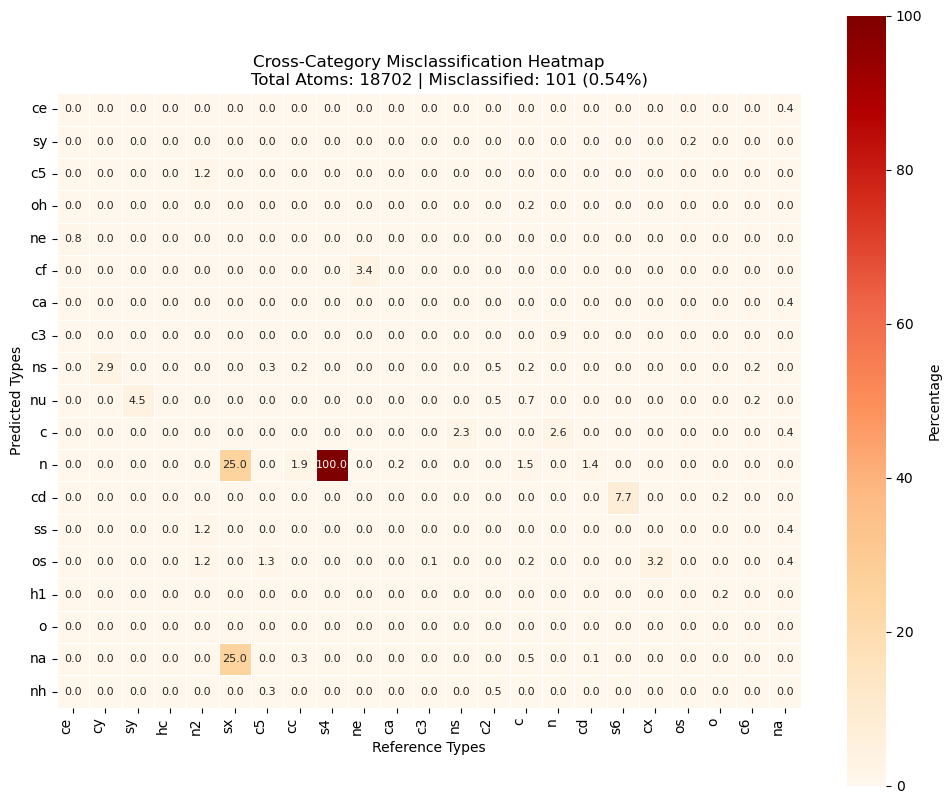

In [5]:
plot_detailed_cross_category_heatmap(y_pred=y_pred_GAT, y_true=y_true_GAT)

# Testing GCN_4Layer - 4 layer Graph Conv nn on atom features only with relu activation functions

GCN_4Layer - Number of parameters: 268747


---------KFOLD: 0----------
Epoch - 10: Train Loss: 1.1163 | Val Loss: 1.1035
Epoch - 20: Train Loss: 0.9805 | Val Loss: 0.9870
Epoch - 30: Train Loss: 0.8973 | Val Loss: 0.9110


---------KFOLD: 1----------
Epoch - 10: Train Loss: 0.8387 | Val Loss: 0.8584
Epoch - 20: Train Loss: 0.7876 | Val Loss: 0.8184
Epoch - 30: Train Loss: 0.7513 | Val Loss: 0.7972


---------KFOLD: 2----------
Epoch - 10: Train Loss: 0.7367 | Val Loss: 0.7521
Epoch - 20: Train Loss: 0.7181 | Val Loss: 0.7468
Epoch - 30: Train Loss: 0.7024 | Val Loss: 0.7257


---------KFOLD: 3----------
Epoch - 10: Train Loss: 0.6867 | Val Loss: 0.7151
Epoch - 20: Train Loss: 0.6714 | Val Loss: 0.7038
Epoch - 30: Train Loss: 0.6616 | Val Loss: 0.7129


---------KFOLD: 4----------
Epoch - 10: Train Loss: 0.6511 | Val Loss: 0.6632
Epoch - 20: Train Loss: 0.6398 | Val Loss: 0.6765
Epoch - 30: Train Loss: 0.6304 | Val Loss: 0.6893


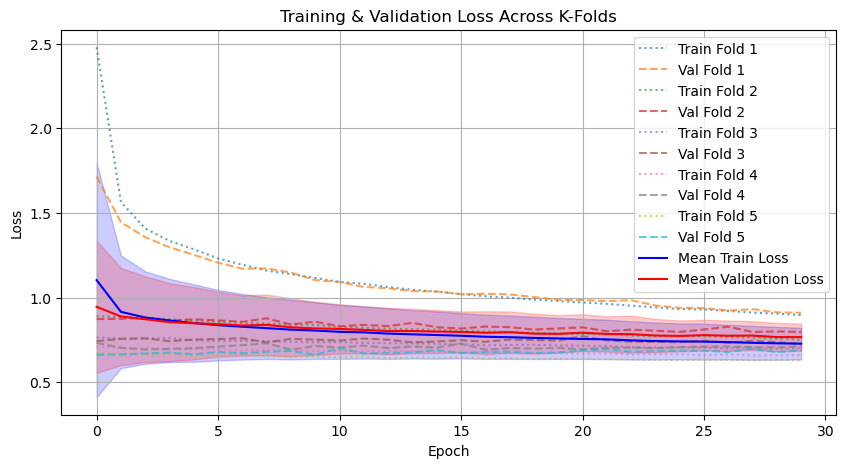

Evaluation Metrics: {'Accuracy': 0.7559084589883435, 'F1-score': 0.743741976492389}


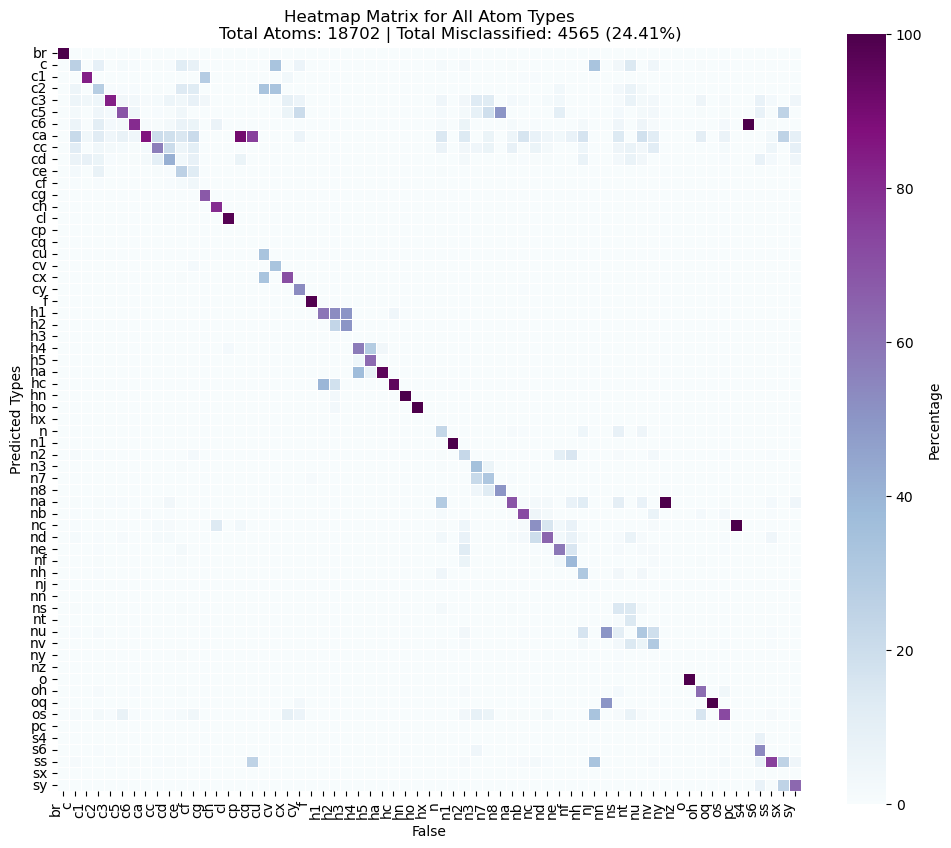

In [6]:
import importlib
import atoMLtype
importlib.reload(atoMLtype.GNN.GNNmodel)
from atoMLtype.GNN.GNNmodel import GCN_4Layer

# Initialize baselineGNN for classification
model_GCN_4Layer = GCN_4Layer(num_node_features=num_node_feat, num_atom_types=num_y_ATs, hidden_dim=512)
trainer_GCN_4Layer = GNNTrainer(model_GCN_4Layer, dataset=train_dataset, batch_size=32, learning_rate=0.001, \
                      epochs=30, k_folds=5, task="classification", random_seed=21)
trainer_GCN_4Layer.train()
metrics_GCN_4Layer = trainer_GCN_4Layer.evaluate_model(test_dataset)

y_true_GCN_4Layer, y_pred_GCN_4Layer = trainer_GCN_4Layer.predict(test_dataset)

plot_full_heatmap(y_true=y_true_GCN_4Layer, y_pred=y_pred_GCN_4Layer)

GAT_4L - Number of parameters: 485643


---------KFOLD: 0----------
Epoch - 10: Train Loss: 0.6970 | Val Loss: 0.7093
Epoch - 20: Train Loss: 0.6309 | Val Loss: 0.6501
Epoch - 30: Train Loss: 0.6018 | Val Loss: 0.6763


---------KFOLD: 1----------
Epoch - 10: Train Loss: 0.5826 | Val Loss: 0.5926
Epoch - 20: Train Loss: 0.5604 | Val Loss: 0.5950
Epoch - 30: Train Loss: 0.5580 | Val Loss: 0.5924


---------KFOLD: 2----------
Epoch - 10: Train Loss: 0.5380 | Val Loss: 0.5473
Epoch - 20: Train Loss: 0.5313 | Val Loss: 0.5625
Epoch - 30: Train Loss: 0.5281 | Val Loss: 0.5639


---------KFOLD: 3----------
Epoch - 10: Train Loss: 0.5148 | Val Loss: 0.5410
Epoch - 20: Train Loss: 0.5256 | Val Loss: 0.5922
Epoch - 30: Train Loss: 0.4930 | Val Loss: 0.5563


---------KFOLD: 4----------
Epoch - 10: Train Loss: 0.4973 | Val Loss: 0.5417
Epoch - 20: Train Loss: 0.5193 | Val Loss: 0.5665
Epoch - 30: Train Loss: 0.4751 | Val Loss: 0.5497


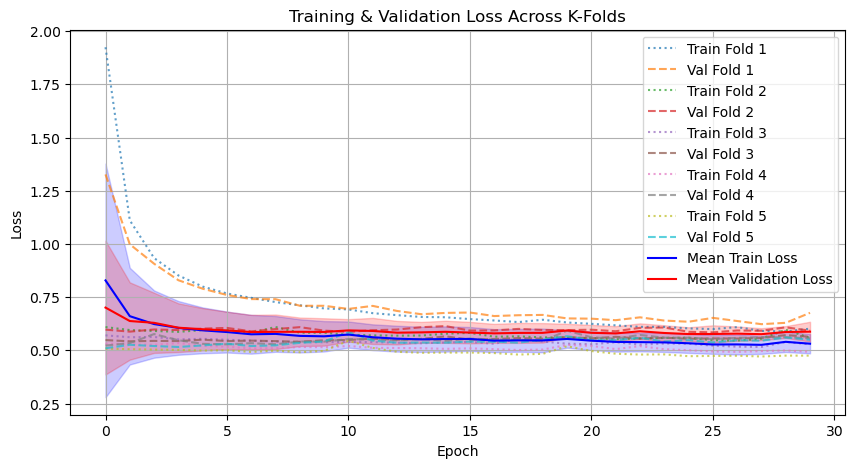

Evaluation Metrics: {'Accuracy': 0.8017859052507753, 'F1-score': 0.7933230661301358}


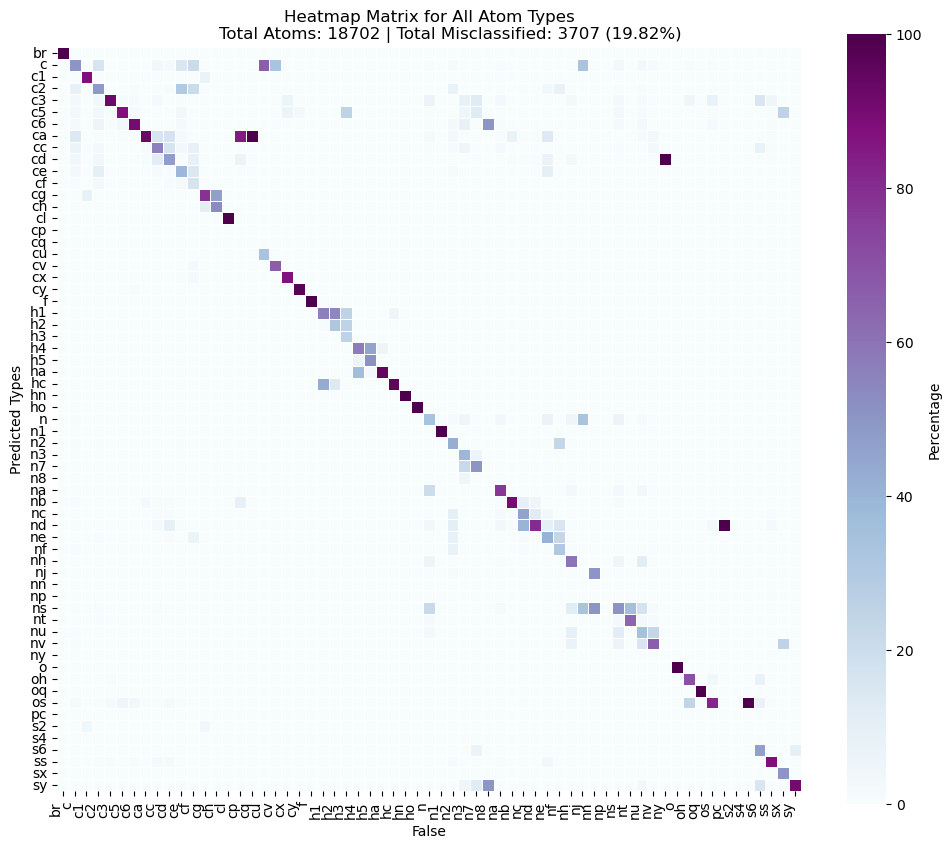

In [7]:
import importlib
import atoMLtype
importlib.reload(atoMLtype.GNN.GNNmodel)
from atoMLtype.GNN.GNNmodel import GAT_4L

# Initialize baselineGNN for classification
model_GAT_4L = GAT_4L(num_node_features=num_node_feat, num_atom_types=num_y_ATs, hidden_dim=128)
trainer_GAT_4L = GNNTrainer(model_GAT_4L, dataset=train_dataset, batch_size=32, learning_rate=0.001, \
                      epochs=30, k_folds=5, task="classification", random_seed=21)
trainer_GAT_4L.train()
metrics_GAT_4L = trainer_GAT_4L.evaluate_model(test_dataset)

y_true_GAT_4L, y_pred_GAT_4L = trainer_GAT_4L.predict(test_dataset)

plot_full_heatmap(y_true=y_true_GAT_4L, y_pred=y_pred_GAT_4L)

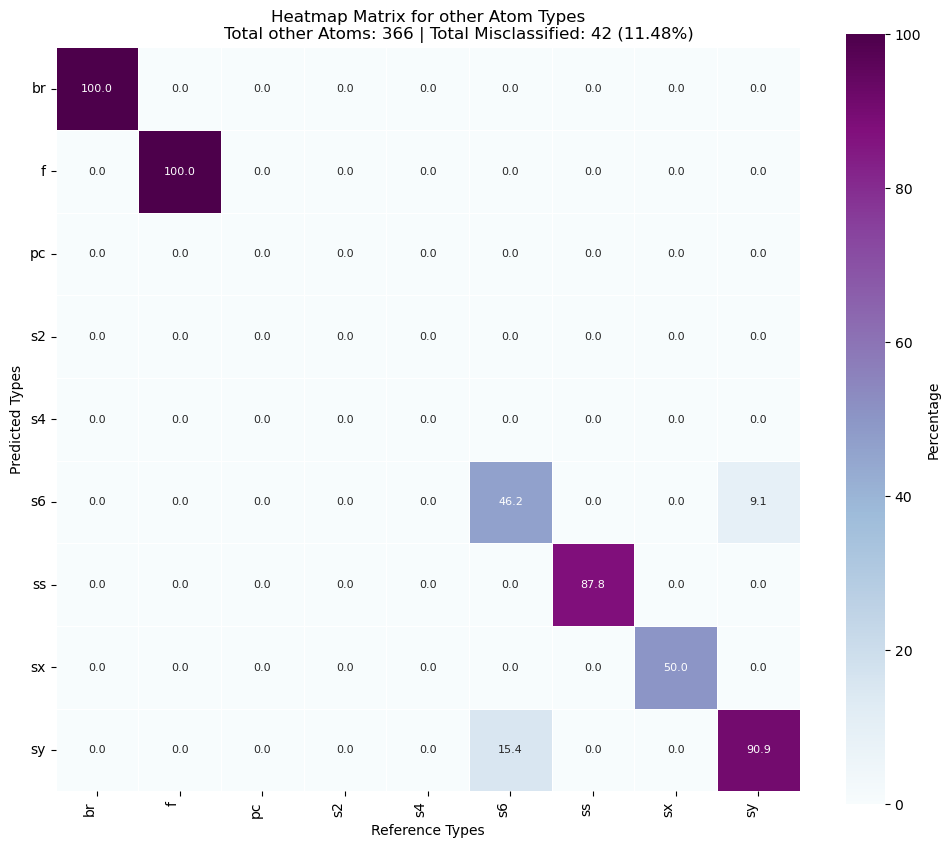

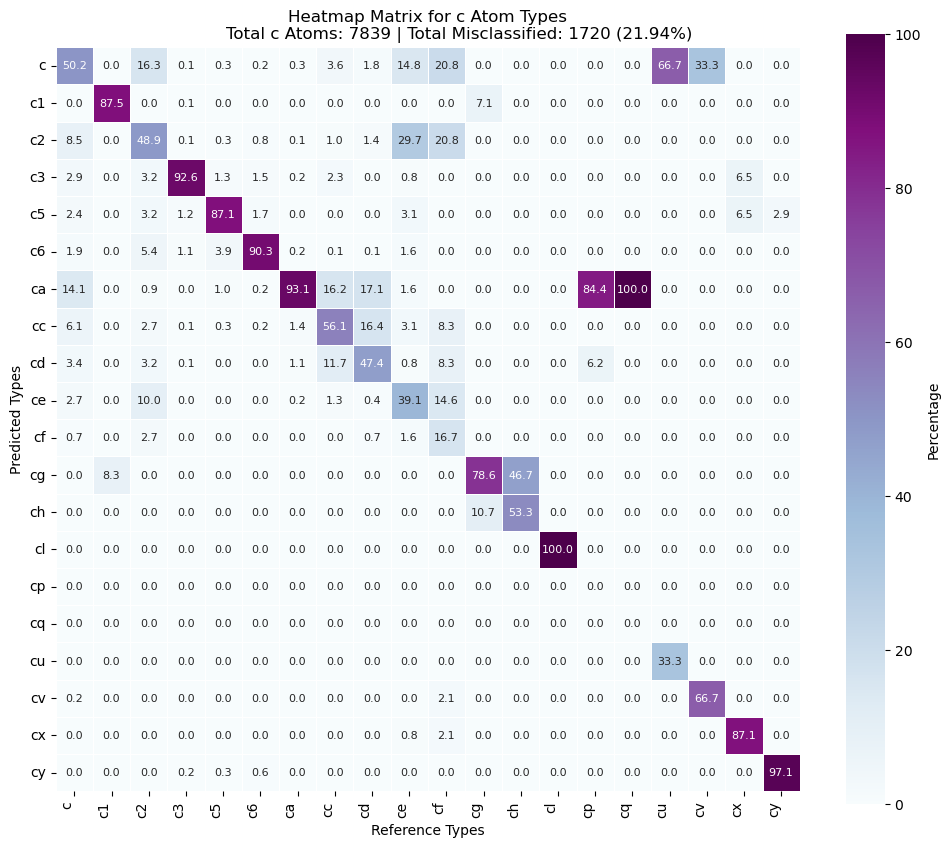

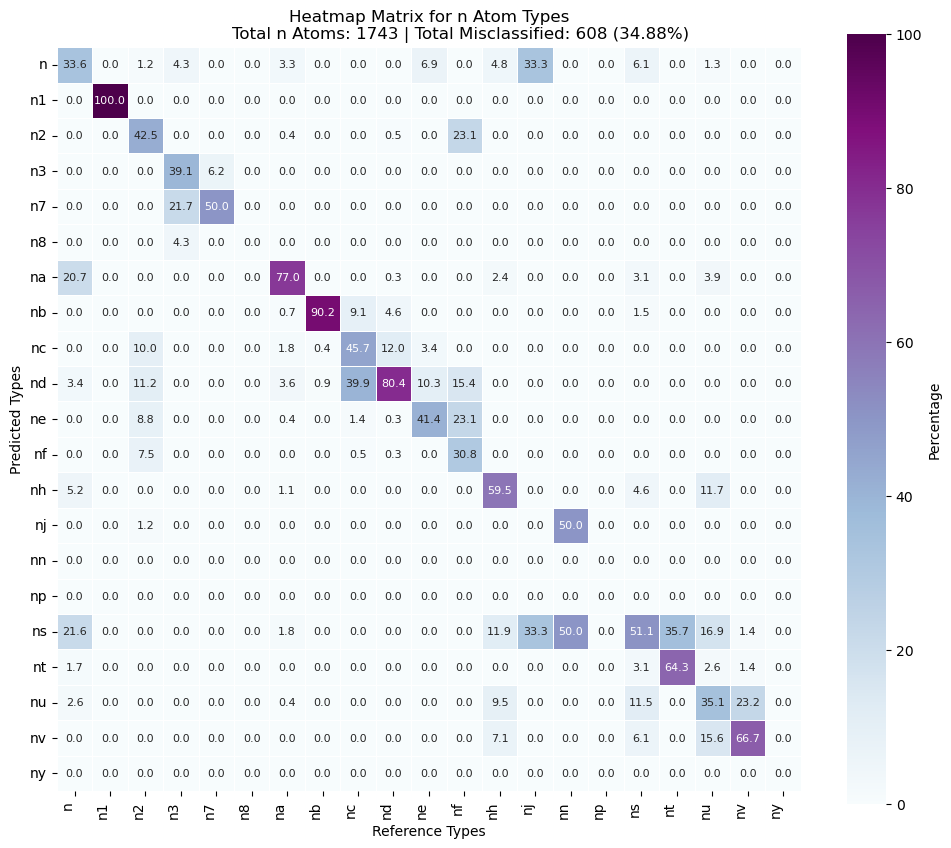

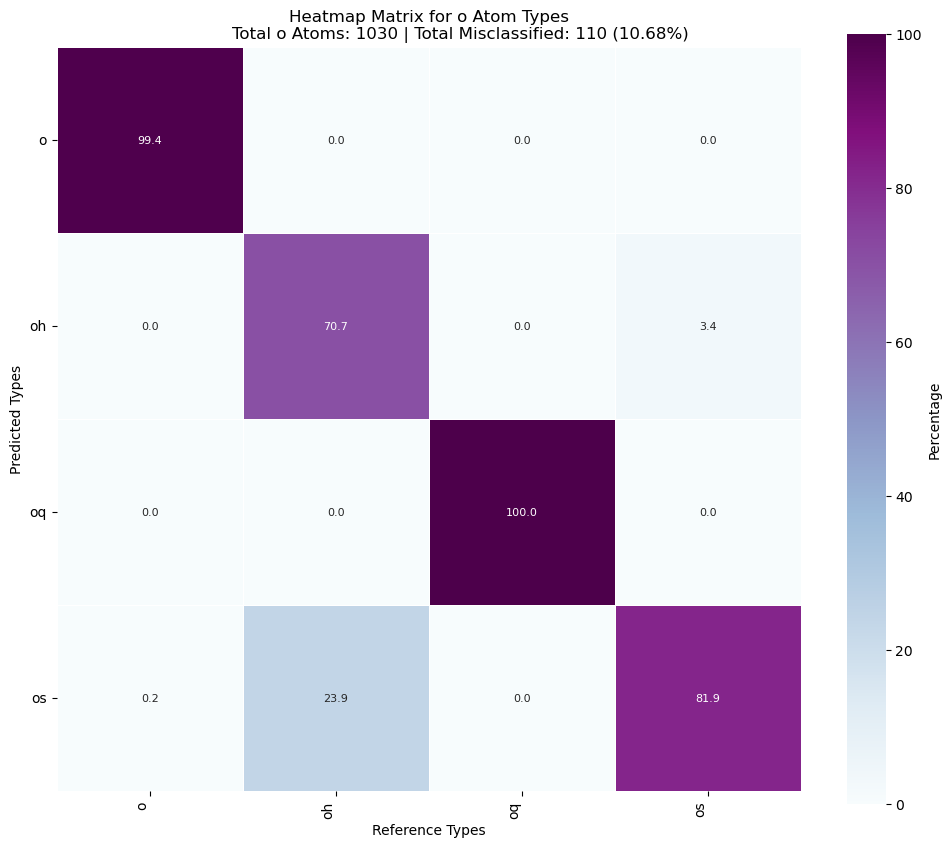

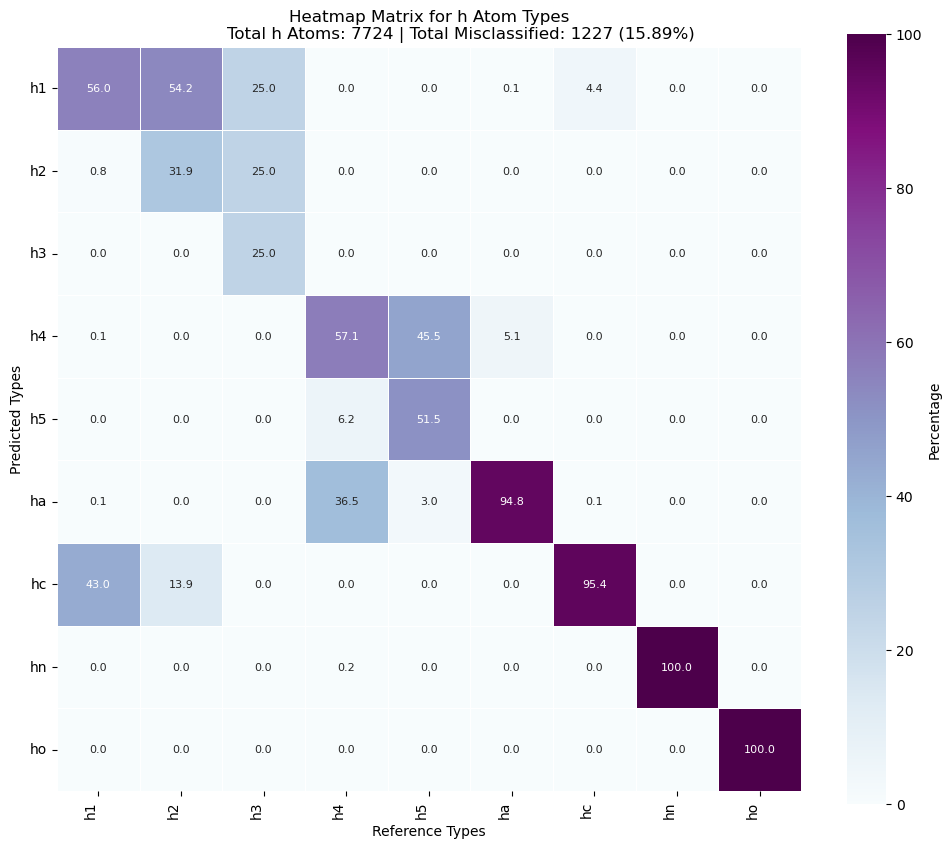

In [8]:
plot_category_heatmap(y_pred=y_pred_GAT_4L, y_true= y_true_GAT_4L)

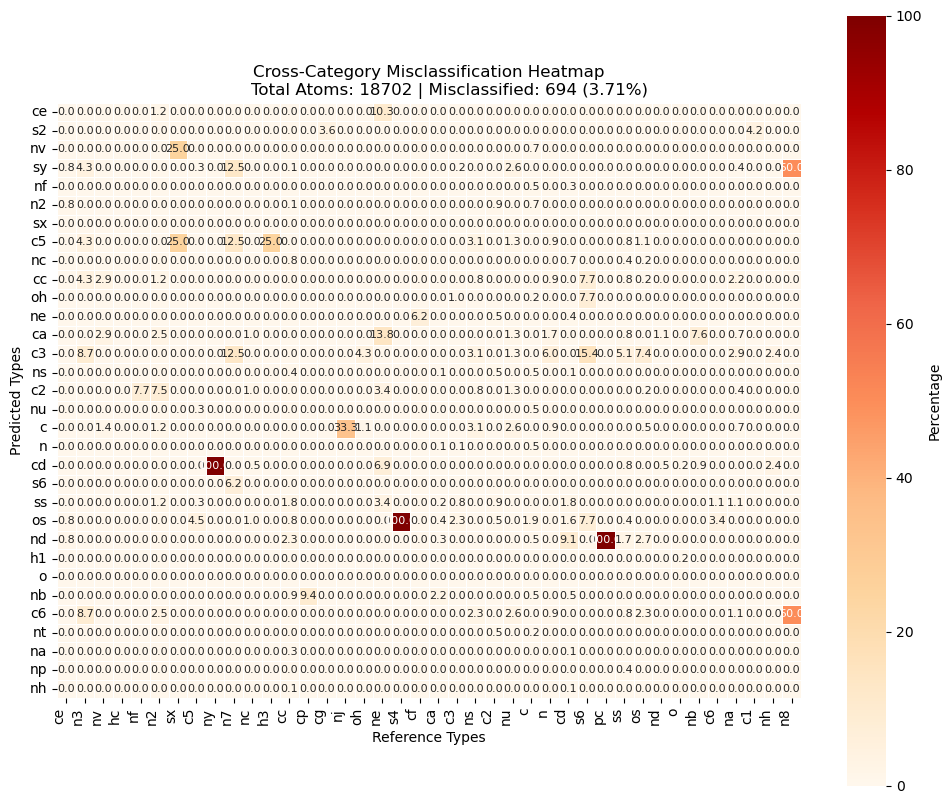

In [9]:
plot_detailed_cross_category_heatmap(y_pred=y_pred_GAT_4L, y_true=y_true_GAT_4L)

# Testing MPNN_4Layer - 4 layer MPNN with MLP of ({2*IC} Linear, ReLU, Dropout, {IC}Linear) nn on atom features only with relu activation functions

MPNN_4L - Number of parameters: 133227


---------KFOLD: 0----------
Epoch - 10: Train Loss: 0.5762 | Val Loss: 0.5088
Epoch - 20: Train Loss: 0.4981 | Val Loss: 0.4566
Epoch - 30: Train Loss: 0.4688 | Val Loss: 0.4457


---------KFOLD: 1----------
Epoch - 10: Train Loss: 0.4482 | Val Loss: 0.4277
Epoch - 20: Train Loss: 0.4358 | Val Loss: 0.4195
Epoch - 30: Train Loss: 0.4272 | Val Loss: 0.4108


---------KFOLD: 2----------
Epoch - 10: Train Loss: 0.4171 | Val Loss: 0.4002
Epoch - 20: Train Loss: 0.4083 | Val Loss: 0.3948
Epoch - 30: Train Loss: 0.4031 | Val Loss: 0.3945


---------KFOLD: 3----------
Epoch - 10: Train Loss: 0.3992 | Val Loss: 0.3858
Epoch - 20: Train Loss: 0.3924 | Val Loss: 0.3874
Epoch - 30: Train Loss: 0.3881 | Val Loss: 0.3916


---------KFOLD: 4----------
Epoch - 10: Train Loss: 0.3872 | Val Loss: 0.3734
Epoch - 20: Train Loss: 0.3844 | Val Loss: 0.3777
Epoch - 30: Train Loss: 0.3811 | Val Loss: 0.3777


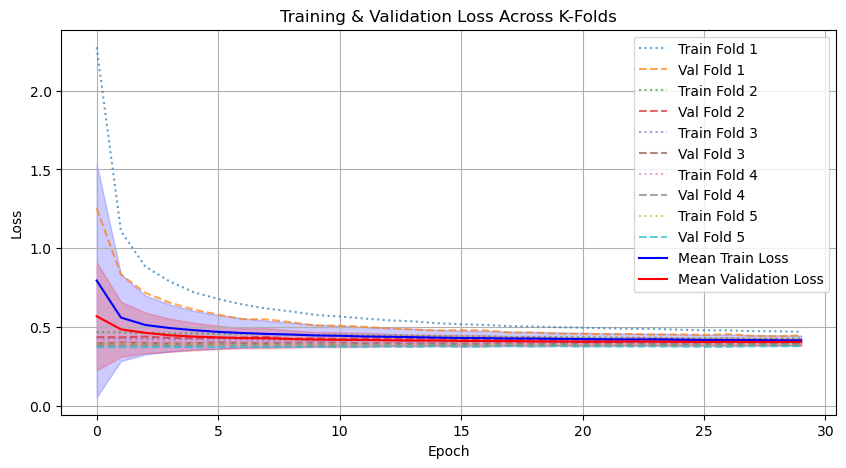

Evaluation Metrics: {'Accuracy': 0.8566998182012618, 'F1-score': 0.8490660045278433}


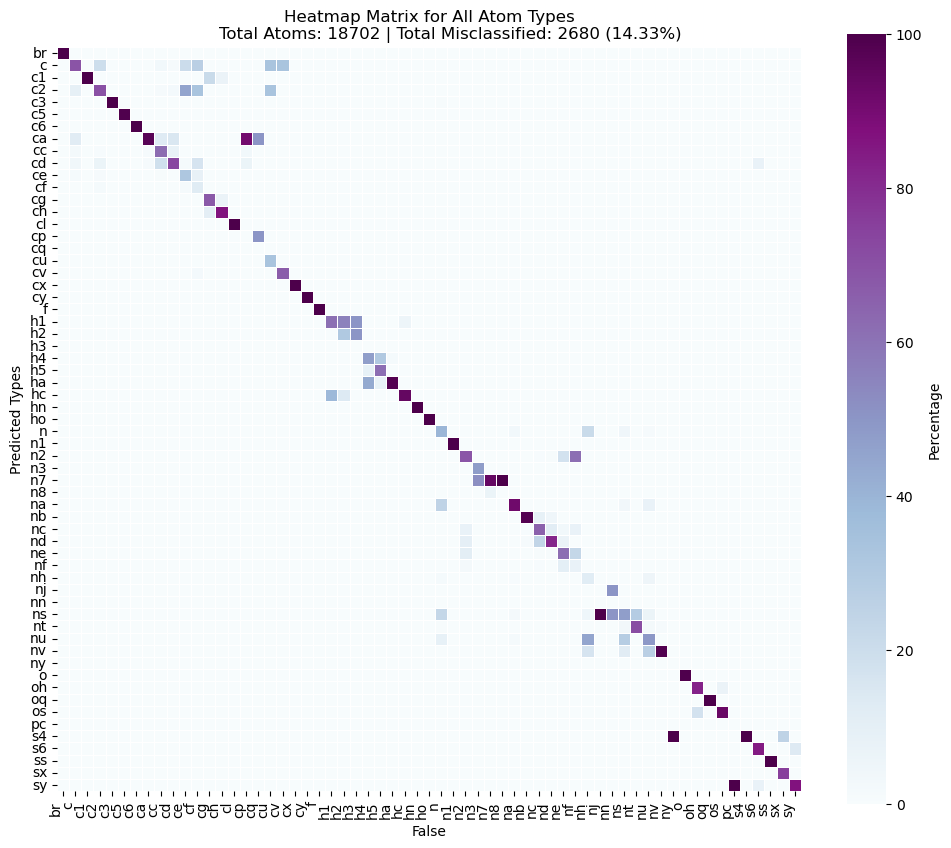

In [10]:
import importlib
import atoMLtype
importlib.reload(atoMLtype.GNN.GNNmodel)
from atoMLtype.GNN.GNNmodel import MPNN_4L

# Initialize baselineGNN for classification
model_MPNN_4L = MPNN_4L(num_node_features=num_node_feat, num_atom_types=num_y_ATs, hidden_dim=128)
trainer_MPNN_4L = GNNTrainer(model_MPNN_4L, dataset=train_dataset, batch_size=32, learning_rate=0.001, \
                      epochs=30, k_folds=5, task="classification", random_seed=21)
trainer_MPNN_4L.train()
metrics_MPNN_4L = trainer_MPNN_4L.evaluate_model(test_dataset)

y_true_MPNN_4L, y_pred_MPNN_4L = trainer_MPNN_4L.predict(test_dataset)

plot_full_heatmap(y_true=y_true_MPNN_4L, y_pred=y_pred_MPNN_4L)

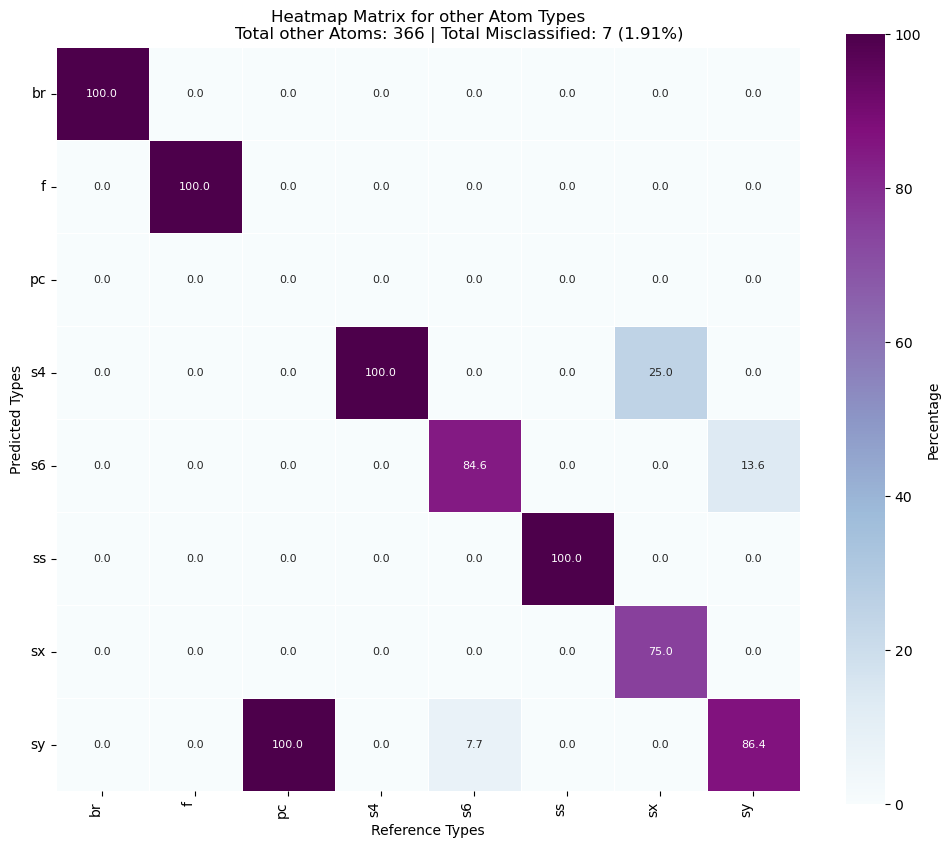

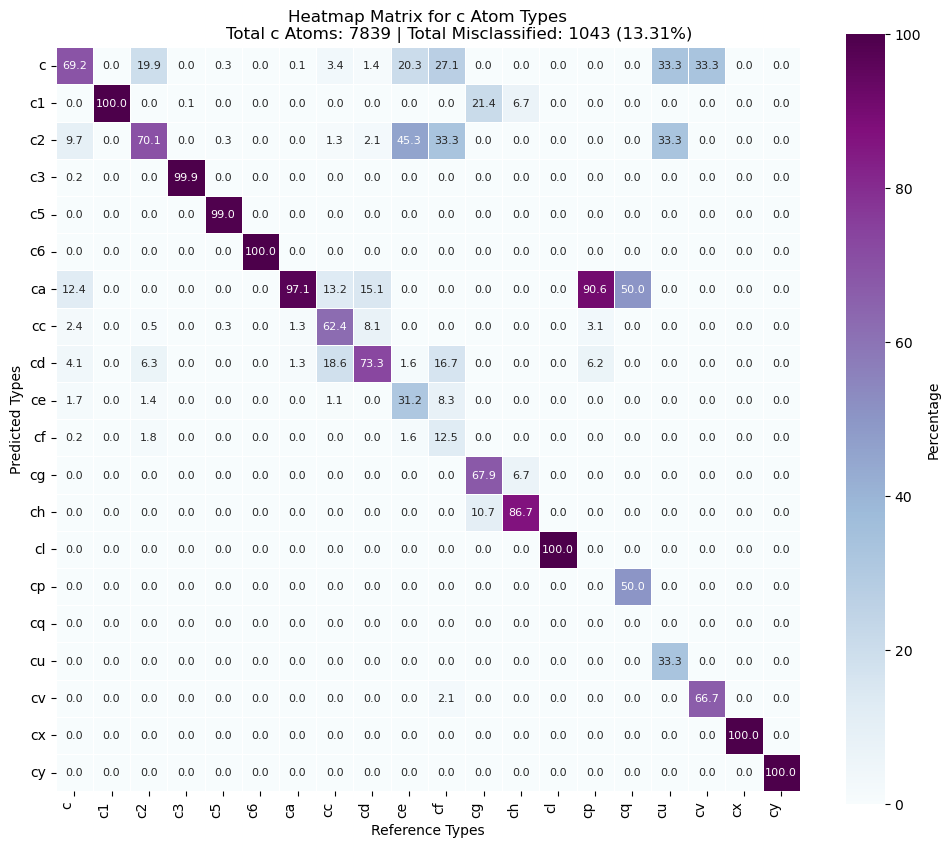

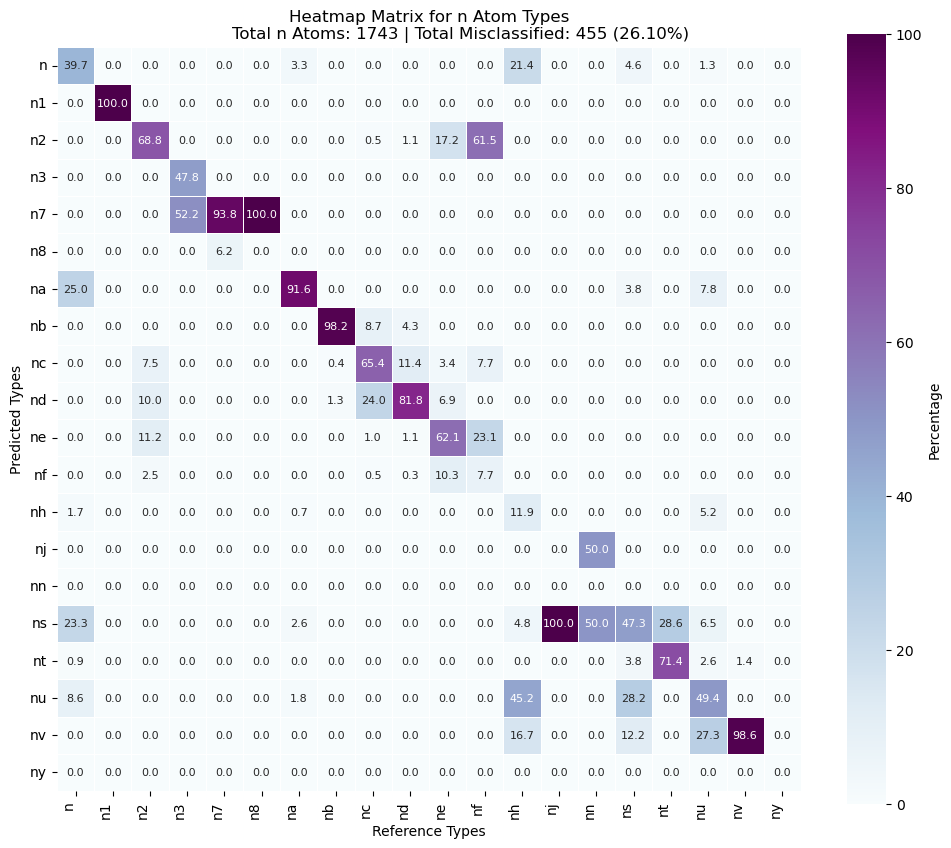

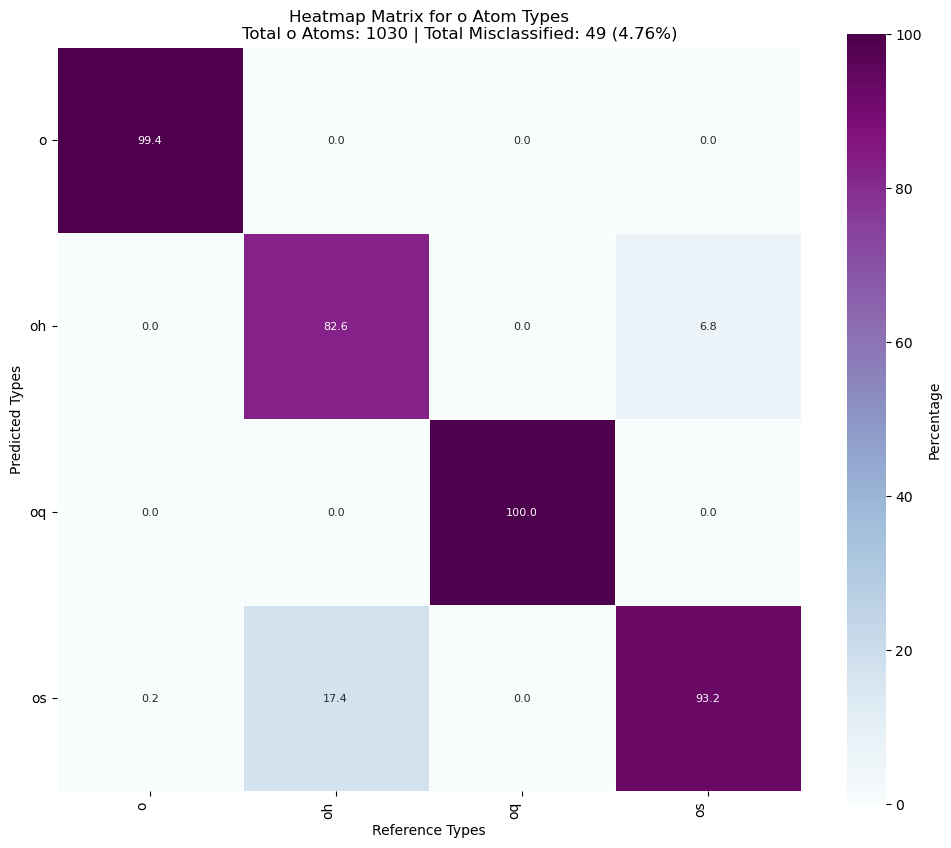

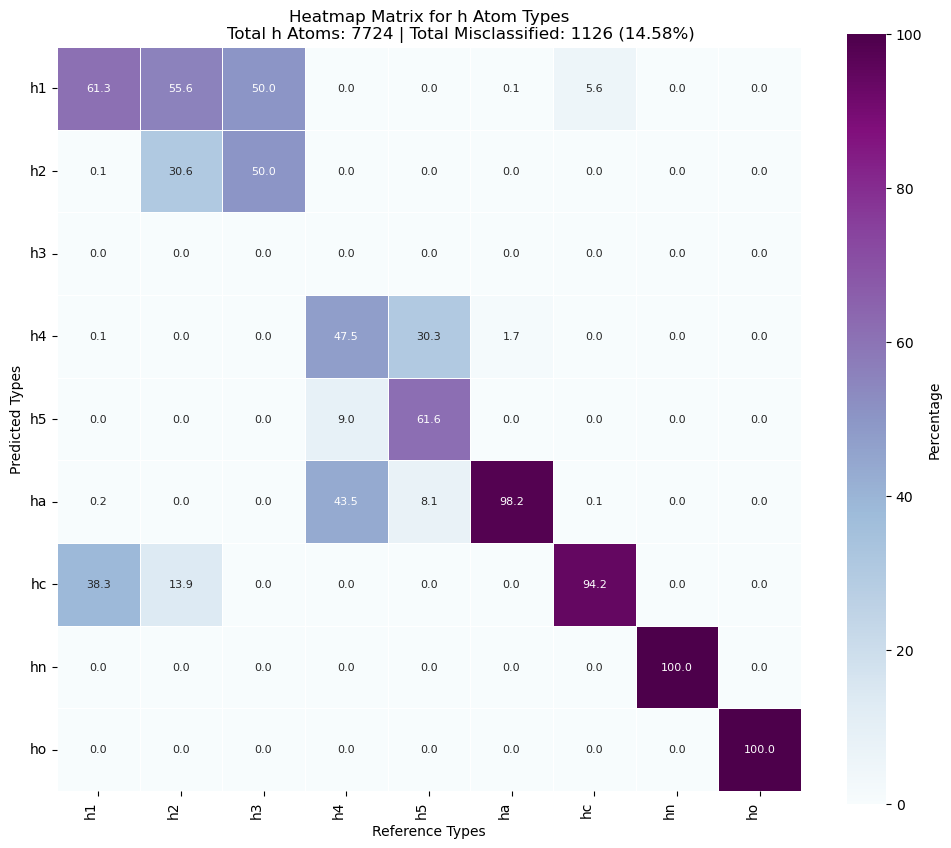

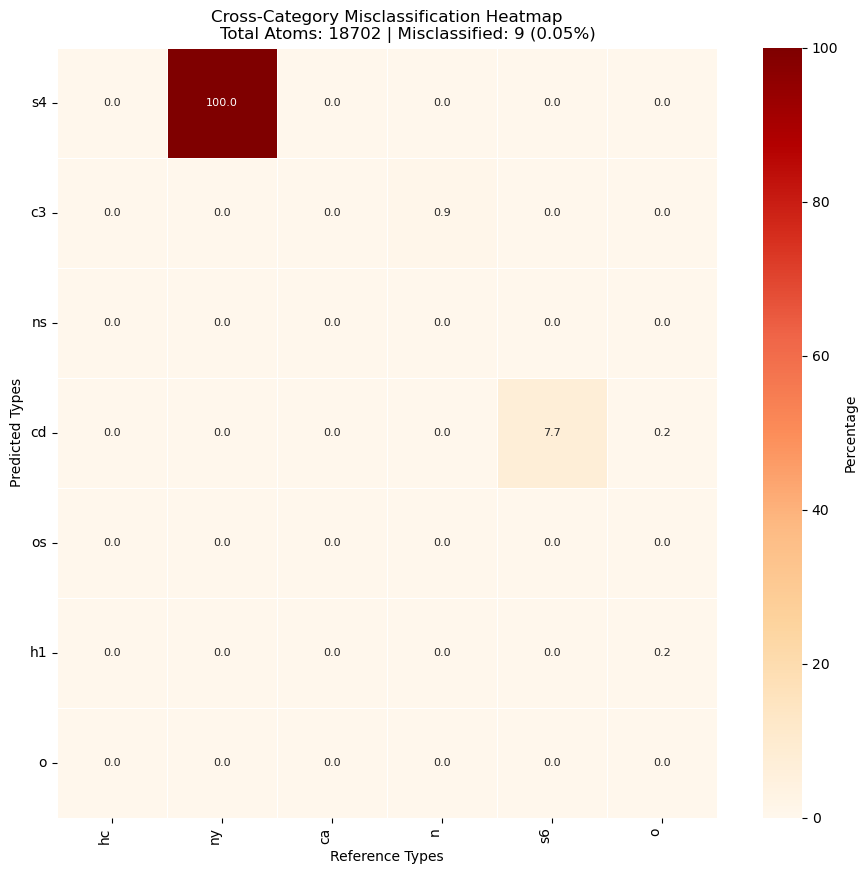

In [11]:
plot_category_heatmap(y_true=y_true_MPNN_4L, y_pred=y_pred_MPNN_4L)

plot_detailed_cross_category_heatmap(y_true=y_true_MPNN_4L, y_pred=y_pred_MPNN_4L)